In [1]:
# import libraries
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller

from tqdm import tqdm_notebook
from itertools import product
from typing import Union

import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
# read in data
df = pd.read_csv('../datasets/TX-Data/soil_station_cleanedup/SM_1_filled.dat', sep=",", parse_dates=["Date"], index_col="Date")

In [3]:
# Slice data to isolate 2015-2020
df = df[(df.index > "2014-12-31 23:00") & (df.index < "2020-12-31 23:00")]

In [4]:
# Replace inf values and Fill nan values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.mean(), inplace=True)

df

,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Flag
Date,,,,,,,,,,
2015-01-01 00:00:00,0.0,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,3
2015-01-01 01:00:00,0.0,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,3
2015-01-01 02:00:00,0.0,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,3
2015-01-01 03:00:00,0.0,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,3
2015-01-01 04:00:00,0.0,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,3
...,...,...,...,...,...,...,...,...,...,...
2020-12-31 18:00:00,0.0,0.249,0.194,0.181,0.099,5.50,7.25,8.91,14.84,0
2020-12-31 19:00:00,0.0,0.242,0.193,0.182,0.099,5.46,6.95,8.62,14.71,0
2020-12-31 20:00:00,0.0,0.236,0.191,0.182,0.099,5.43,6.80,8.40,14.58,0


In [5]:
# Reseample with monthly mean
df = df.resample('M').mean()

In [6]:
# removes spaces in the column names
def remove_spaces(df):
    df.columns = df.columns.str.replace(' ','')
    df['Ppt'] = df['Ppt'].astype(float)
    df['SWC_5'] = df['SWC_5'].astype(float)
    df['SWC_10'] = df['SWC_10'].astype(float)
    df['SWC_20'] = df['SWC_20'].astype(float)
    df['SWC_50'] = df['SWC_50'].astype(float)
    df['T_5'] = df['T_5'].astype(float)
    df['T_10'] = df['T_10'].astype(float)
    df['T_20'] = df['T_20'].astype(float)
    df['T_50'] = df['T_50'].astype(float)
    df.drop(['Flag'], axis=1)

In [7]:
# remove column name spaces of each DataFrame 
remove_spaces(df)

In [8]:
# view head of data frame
df.head(10)

,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Flag
Date,,,,,,,,,,
2015-01-31,0.071882,0.165465,0.206012,0.176745,0.172145,8.035282,8.498468,8.817460,10.302849,84.755376
2015-02-28,0.006384,0.135112,0.183321,0.159565,0.170021,11.548378,12.082574,12.436875,13.595982,2.166667
2015-03-31,0.077715,0.161151,0.206856,0.179360,0.183304,15.662030,15.542500,15.363280,14.885013,27.526882
2015-04-30,0.081833,0.112149,0.165574,0.144571,0.151367,22.679444,22.647861,22.511958,21.821833,148.622222
2015-05-31,0.294946,0.154694,0.191805,0.167050,0.158964,24.503038,24.378629,24.184960,23.433817,70.838710
2015-06-30,0.078653,0.109781,0.154011,0.129496,0.150835,30.193750,29.889847,29.491208,27.877972,45.622222
2015-07-31,0.037890,0.066015,0.120251,0.103612,0.102593,34.934960,34.478911,33.961707,31.657782,0.000000
2015-08-31,0.001358,0.069781,0.118848,0.098964,0.094866,35.495027,35.246237,34.918387,33.315901,110.107527
2015-09-30,0.011972,0.062437,0.104646,0.093247,0.091142,32.438167,32.406736,32.278639,31.611889,34.483333


In [9]:
# Verify shape of data frame
df.shape

(72, 10)

## Visualization 

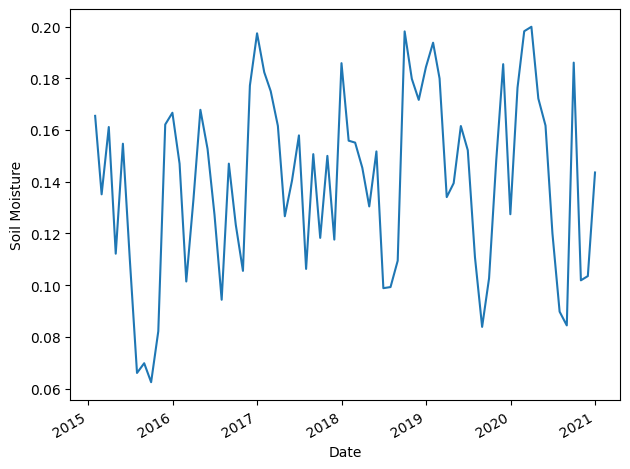

In [10]:
# Visualize Tair Montly Data for 2015
fig, ax = plt.subplots()

ax.plot(df.SWC_5)
ax.set_xlabel('Date')
ax.set_ylabel('Soil Moisture')


fig.autofmt_xdate()
plt.tight_layout()



## Exploration 

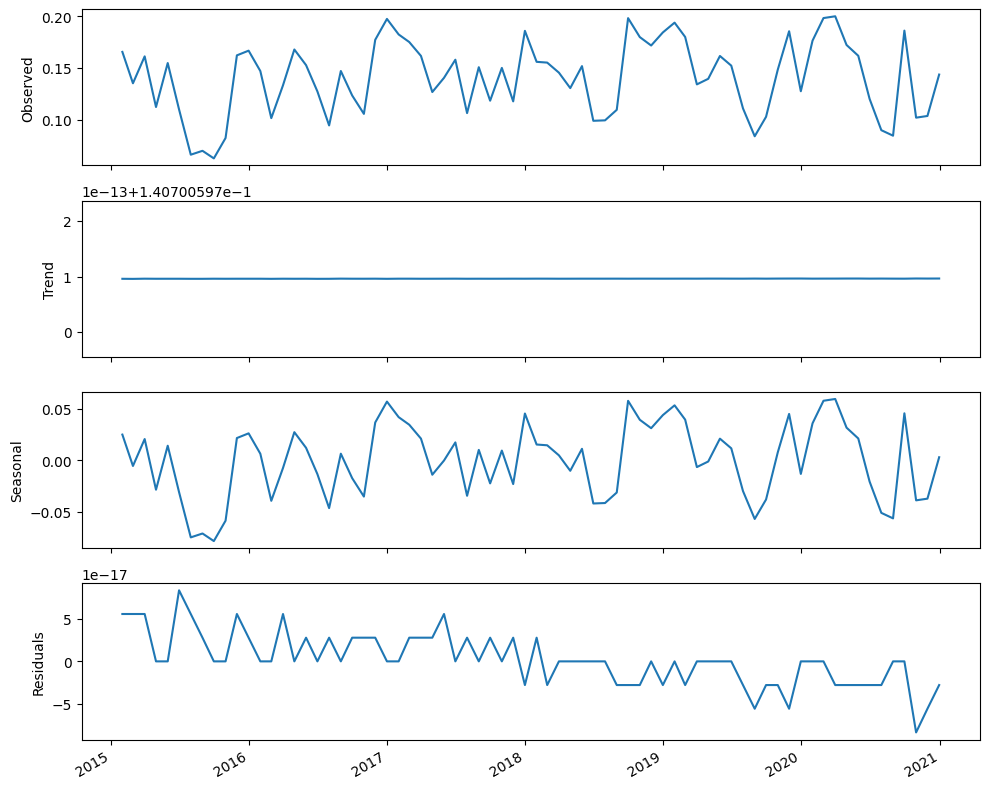

In [11]:
# Decompose data  to view seasonality, trend, and residuals
decomposition = STL(df.SWC_5, period=72).fit()

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10,8))

ax1.plot(decomposition.observed)
ax1.set_ylabel('Observed')

ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')

ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')

ax4.plot(decomposition.resid)
ax4.set_ylabel('Residuals')


fig.autofmt_xdate()
plt.tight_layout()



## Modeling 

In [12]:
# Preform Ad Fuller Test to check for stationarity
ad_fuller_result = adfuller(df.SWC_5)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -5.133877791114823
p-value: 1.1978906057605379e-05


In [13]:
# Difference Data and check Ad Fuller test again
Tair_diff = np.diff(df.SWC_5, n=1)

ad_fuller_result = adfuller(Tair_diff)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -5.173726958648661
p-value: 9.945459930279263e-06


### Train/test split 

In [14]:
# split data into train and test
train_len = 60
test_len = 12
total_len = 72

train = df.SWC_5[:train_len]
test = df.SWC_5[train_len:]

test

Date
2020-01-31    0.176367
2020-02-29    0.198210
2020-03-31    0.199926
2020-04-30    0.172165
2020-05-31    0.161712
2020-06-30    0.119962
2020-07-31    0.089724
2020-08-31    0.084403
2020-09-30    0.186056
2020-10-31    0.101843
2020-11-30    0.103483
2020-12-31    0.143557
Freq: M, Name: SWC_5, dtype: float64

In [15]:
# incorperate exog data
exog = df.Ppt[:train_len]

# exog_full = np.empty([72, 5])
# exog_full[:, 0] = df.Ppt
# exog_full[:, 1] = df.RH
# exog_full[:, 2] = df.Windspeed
# exog_full[:, 3] = df.Winddirection
# exog_full[:, 4] = df.Srad


# exog_full= exog_full.drop('Tair', axis=1)

### SARIMA(p,0,q)(P,0,Q)<sub>12<sub> 

In [16]:
# Define SARIMA model
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX

def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm_notebook(order_list):
        try: 
            model = SARIMAX(
                endog,
                exog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        print([order, aic])
        results.append([order, model.aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [17]:
# Define range of parameter's to check
ps = range(0, 2, 1)
qs = range(0, 2, 1)
Ps = range(0, 2, 1)
Qs = range(0, 2, 1)

order_list = list(product(ps, qs, Ps, Qs))

d = 0
D = 0
s = 12

In [18]:
# Find best set of parameters using the AIC
SARIMA_result_df = optimize_SARIMAX(train, exog, order_list, d, D, s)
SARIMA_result_df

  0%|          | 0/16 [00:00<?, ?it/s]

[(0, 0, 0, 0), -100.66962687953806]
[(0, 0, 0, 1), -122.06606180726558]
[(0, 0, 1, 0), -212.77145299199967]
[(0, 0, 1, 1), -219.9078397617535]
[(0, 1, 0, 0), -139.30169603628013]
[(0, 1, 0, 1), -165.869840134878]
[(0, 1, 1, 0), -219.54466114189978]
[(0, 1, 1, 1), -227.01358425899107]
[(1, 0, 0, 0), -249.29906221917773]
[(1, 0, 0, 1), -248.27276020660094]
[(1, 0, 1, 0), -248.49381472604307]
[(1, 0, 1, 1), -248.7428056660799]
[(1, 1, 0, 0), -248.03670349921185]
[(1, 1, 0, 1), -247.6228665529547]
[(1, 1, 1, 0), -248.44692178994575]
[(1, 1, 1, 1), -252.7191267791839]


,"(p,q,P,Q)",AIC
0,"(1, 1, 1, 1)",-252.719127
1,"(1, 0, 0, 0)",-249.299062
2,"(1, 0, 1, 1)",-248.742806
3,"(1, 0, 1, 0)",-248.493815
4,"(1, 1, 1, 0)",-248.446922
5,"(1, 0, 0, 1)",-248.272760
6,"(1, 1, 0, 0)",-248.036703
7,"(1, 1, 0, 1)",-247.622867
8,"(0, 1, 1, 1)",-227.013584
9,"(0, 0, 1, 1)",-219.907840


In [19]:
# Define and fit SARIMAX model
SARIMA_model = SARIMAX(train, order=((SARIMA_result_df.iloc[0][0][0]), 0, SARIMA_result_df.iloc[0][0][1]), seasonal_order = (SARIMA_result_df.iloc[0][0][2], 0, SARIMA_result_df.iloc[0][0][3], total_len), simple_differencing=False, enforce_stationarity=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)

print(SARIMA_model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              SWC_5   No. Observations:                   60
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 72)   Log Likelihood                   0.000
Date:                            Fri, 28 Jul 2023   AIC                             10.000
Time:                                    12:33:17   BIC                                nan
Sample:                                01-31-2015   HQIC                               nan
                                     - 12-31-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9797         -0       -inf      0.000       0.980       0.980
ma.L1         -0.2224         -0   

## Forecasting 

In [20]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    
    total_len = train_len + horizon
    end_idx = train_len
    
    
    if method == 'last_season':
        pred_last_season = []
        
        
        for i in range(train_len, total_len, window):
            last_season = df.SWC_5[i-window:i]
            pred_last_season.extend(last_season)
            
        return pred_last_season
    
    elif method == 'SARIMA':
        pred_SARIMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df.SWC_5[:i], order=(SARIMA_result_df.iloc[0][0][0], 0, SARIMA_result_df.iloc[0][0][1]), seasonal_order = (SARIMA_result_df.iloc[0][0][2], 0, SARIMA_result_df.iloc[0][0][3], 12), simple_differencing=False)
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean[-window:]
            pred_SARIMA.extend(oos_pred)
            
        return pred_SARIMA

In [21]:
pred_df = df[train_len:]

pred_df

,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Flag
Date,,,,,,,,,,
2020-01-31,0.074691,0.176367,0.150926,0.140007,0.110190,12.987997,13.229691,13.444274,14.462110,17.733871
2020-02-29,0.051379,0.198210,0.174287,0.163825,0.161282,11.964598,12.171322,12.350862,13.246681,100.045977
2020-03-31,0.105417,0.199926,0.176344,0.168164,0.177484,18.767796,18.702177,18.560538,18.051559,28.946237
2020-04-30,0.114264,0.172165,0.161336,0.158357,0.175725,22.342722,22.164403,21.914347,21.040681,6.400000
2020-05-31,0.209960,0.161712,0.148136,0.141695,0.133820,27.973790,27.767970,27.473065,26.201048,127.669355
2020-06-30,0.020431,0.119962,0.123360,0.120833,0.132532,31.723028,31.340944,30.886764,29.084389,34.133333
2020-07-31,0.012634,0.089724,0.098980,0.100411,0.104659,36.307809,35.781129,35.200847,32.732151,49.561828
2020-08-31,0.009207,0.084403,0.093173,0.096808,0.100655,36.365833,35.945175,35.450511,33.416223,66.521505
2020-09-30,0.198153,0.186056,0.163171,0.152028,0.149914,25.913972,26.172056,26.391444,27.196292,34.177778


In [22]:
# Define rolling forcast structure and create baseline for model by recalling the previous season
TRAIN_LEN = train_len
HORIZON = test_len
WINDOW = int(test_len / 3)

pred_df['last_season'] = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, 'last_season')
pred_df.last_season

Date
2020-01-31    0.102663
2020-02-29    0.148231
2020-03-31    0.185464
2020-04-30    0.127410
2020-05-31    0.176367
2020-06-30    0.198210
2020-07-31    0.199926
2020-08-31    0.172165
2020-09-30    0.161712
2020-10-31    0.119962
2020-11-30    0.089724
2020-12-31    0.084403
Freq: M, Name: last_season, dtype: float64

In [23]:
# Define SARIMA Prediction Dataframe
pred_df['SARIMA'] = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, 'SARIMA')

pred_df.SARIMA

Date
2020-01-31    0.154619
2020-02-29    0.140715
2020-03-31    0.137848
2020-04-30    0.129459
2020-05-31    0.178520
2020-06-30    0.161967
2020-07-31    0.137954
2020-08-31    0.148272
2020-09-30    0.110929
2020-10-31    0.119892
2020-11-30    0.140723
2020-12-31    0.146839
Freq: M, Name: SARIMA, dtype: float64

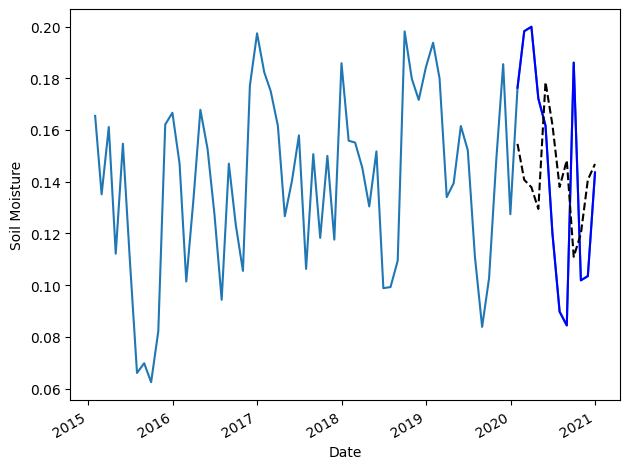

In [24]:
# visualize predictions
fig, ax = plt.subplots()

ax.plot(df.SWC_5)
ax.plot(pred_df.SWC_5, 'b-', label='actual')
# ax.plot(pred_df.last_season, 'r:', label='naive seasonal')
ax.plot(pred_df.SARIMA, 'k--', label='SARIMA')
ax.set_xlabel('Date')
ax.set_ylabel('Soil Moisture')

fig.autofmt_xdate()
plt.tight_layout()



## Evaluate 

In [26]:
mse=mean_squared_error(pred_df.SWC_5,pred_df.SARIMA)
mse

0.0021062985391896104

In [27]:
pred_df.SWC_5

Date
2020-01-31    0.176367
2020-02-29    0.198210
2020-03-31    0.199926
2020-04-30    0.172165
2020-05-31    0.161712
2020-06-30    0.119962
2020-07-31    0.089724
2020-08-31    0.084403
2020-09-30    0.186056
2020-10-31    0.101843
2020-11-30    0.103483
2020-12-31    0.143557
Freq: M, Name: SWC_5, dtype: float64

In [28]:
pred_df.SARIMA

Date
2020-01-31    0.154619
2020-02-29    0.140715
2020-03-31    0.137848
2020-04-30    0.129459
2020-05-31    0.178520
2020-06-30    0.161967
2020-07-31    0.137954
2020-08-31    0.148272
2020-09-30    0.110929
2020-10-31    0.119892
2020-11-30    0.140723
2020-12-31    0.146839
Freq: M, Name: SARIMA, dtype: float64